In [ ]:
SALIANI BOUCHAIB

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import make_moons

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.preprocessing import PolynomialFeatures ,  StandardScaler

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
X,y = make_moons(n_samples=150,noise=0.30, random_state=42)
X_train,X_test,y_train , y_test=train_test_split(X,y,test_size=0.3,random_state=42)

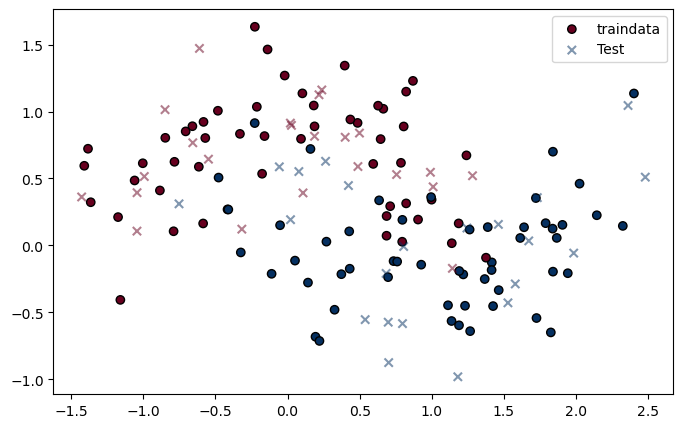

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(X_train[:,0],X_train[:,1],c=y_train,cmap='RdBu',edgecolors='k', label='traindata')
plt.scatter(X_test[:,0],X_test[:,1],c=y_test,cmap='RdBu',marker='x', alpha=0.5 , label='Test')
plt.legend()
plt.show()

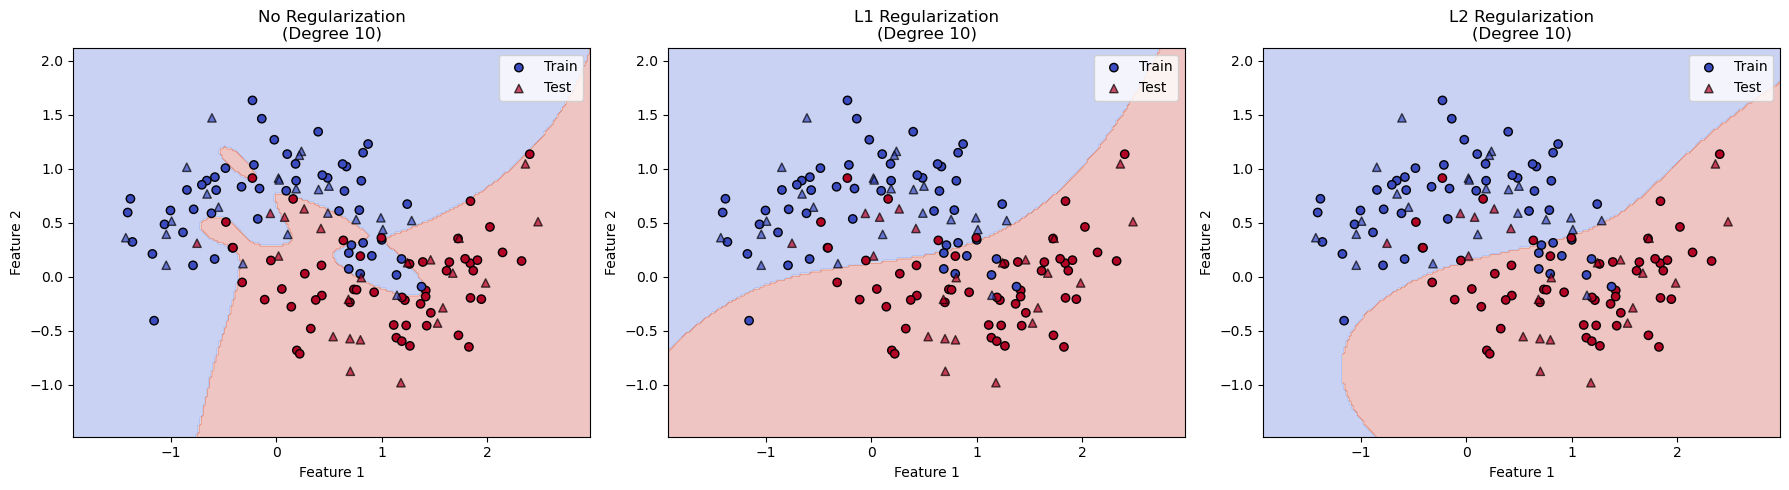

In [ ]:



# Set polynomial degree
degree = 10

# Model 1: No regularization
model_none = Pipeline([
    ('poly', PolynomialFeatures(degree=degree)),
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000))
])

# Model 2: L1 regularization
model_l1 = Pipeline([
    ('poly', PolynomialFeatures(degree=degree)),
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=5000))
])

# Model 3: L2 regularization
model_l2 = Pipeline([
    ('poly', PolynomialFeatures(degree=degree)),
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(penalty='l2', solver='lbfgs', C=0.1, max_iter=5000))
])

# Train models
model_none.fit(X_train, y_train)
model_l1.fit(X_train, y_train)
model_l2.fit(X_train, y_train)

# Function to plot decision boundary
def plot_decision_boundary(model, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm',
               edgecolors='k', marker='o', label='Train')
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm',
               edgecolors='k', marker='^', alpha=0.7, label='Test')

    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend()

# Create 3 plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_decision_boundary(model_none, axes[0], f"No Regularization\n(Degree {degree})")
plot_decision_boundary(model_l1, axes[1], f"L1 Regularization\n(Degree {degree})")
plot_decision_boundary(model_l2, axes[2], f"L2 Regularization\n(Degree {degree})")

plt.tight_layout()
plt.show()

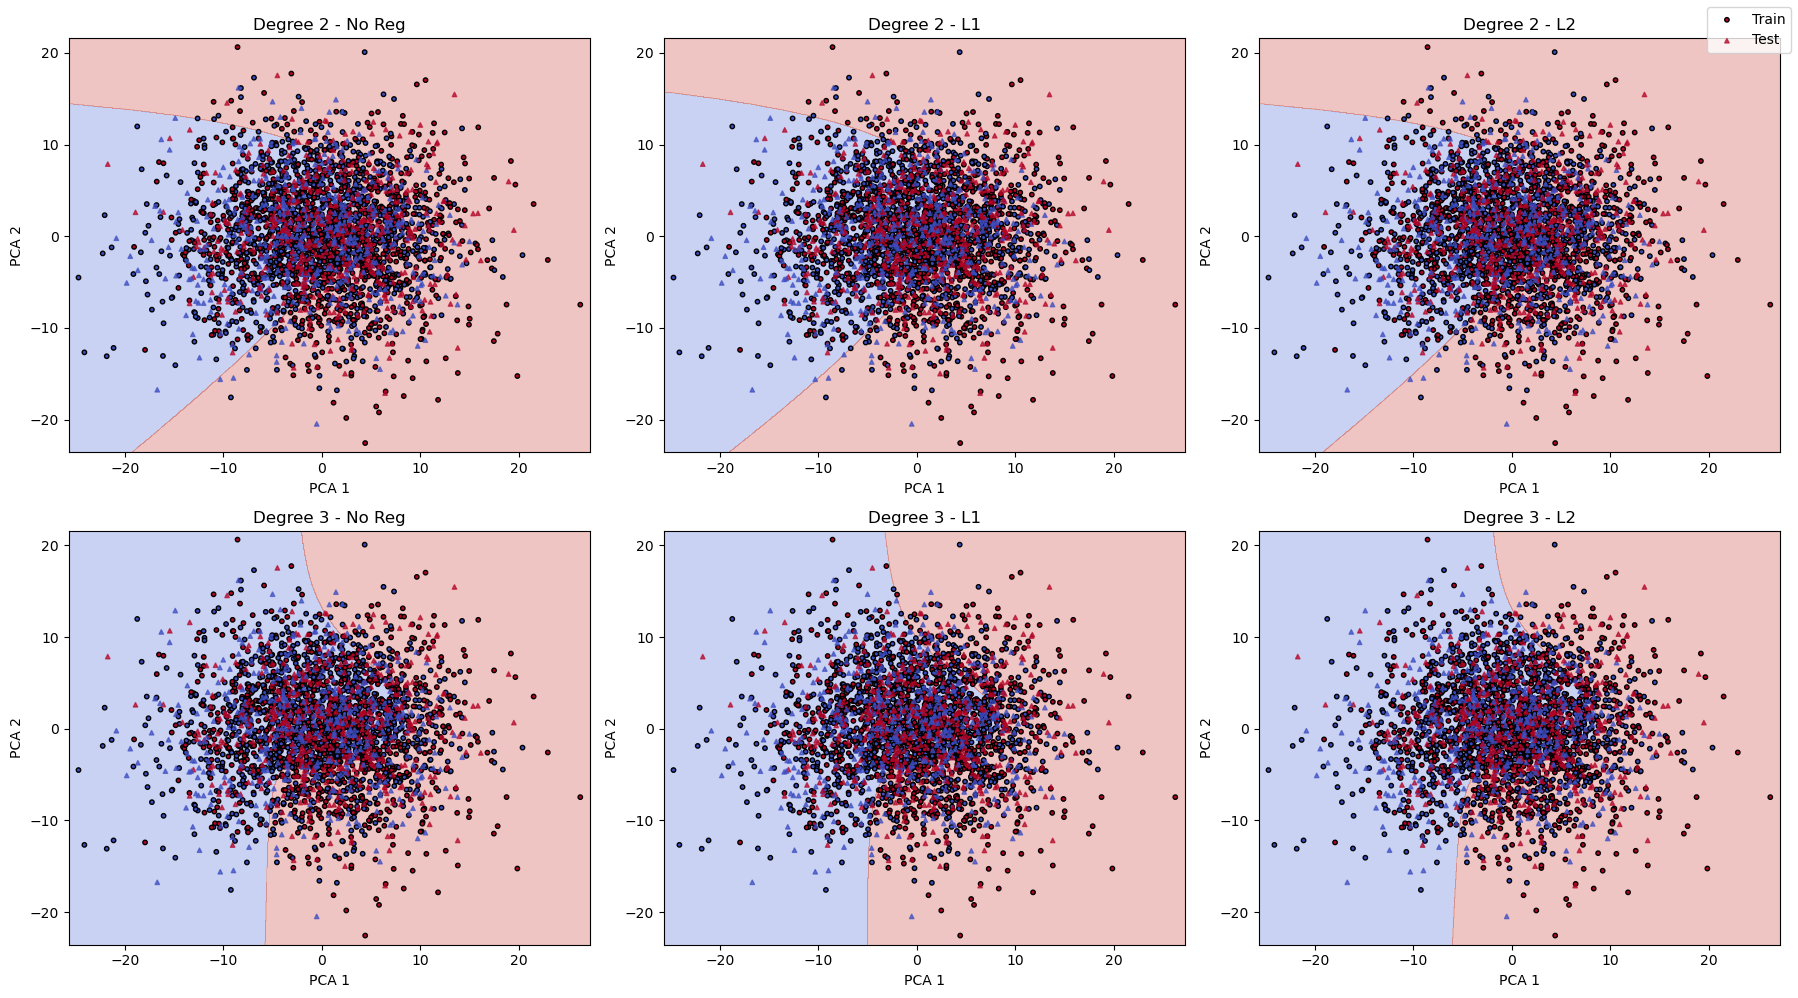

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

# 1) Generate dataset: 3000 samples, 50 features
X, y = make_classification(
    n_samples=3000,
    n_features=50,
    n_informative=10,
    n_redundant=10,
    n_classes=2,
    random_state=42
)

# 2) Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3) Reduce to 2 dimensions for visualization and training
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
X_pca = pca.transform(X)

# 4) Degrees
degrees = [2, 3]

# 5) Function to create model
def create_model(degree, reg_type):
    if reg_type == "none":
        return Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000))
        ])
    elif reg_type == "l1":
        return Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=5000))
        ])
    elif reg_type == "l2":
        return Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(penalty='l2', solver='lbfgs', C=0.1, max_iter=5000))
        ])

# 6) Function to plot decision boundary
def plot_decision_boundary(model, ax, title):
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.05),
        np.arange(y_min, y_max, 0.05)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

    ax.scatter(
        X_train_pca[:, 0], X_train_pca[:, 1],
        c=y_train, cmap='coolwarm', edgecolors='k',
        s=10, label='Train'
    )

    ax.scatter(
        X_test_pca[:, 0], X_test_pca[:, 1],
        c=y_test, cmap='coolwarm', marker='^',
        s=10, alpha=0.7, label='Test'
    )

    ax.set_title(title)
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")

# 7) Create 2x3 figure = 6 plots total
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, degree in enumerate(degrees):
    model_none = create_model(degree, "none")
    model_none.fit(X_train_pca, y_train)
    plot_decision_boundary(model_none, axes[i, 0], f"Degree {degree} - No Reg")

    model_l1 = create_model(degree, "l1")
    model_l1.fit(X_train_pca, y_train)
    plot_decision_boundary(model_l1, axes[i, 1], f"Degree {degree} - L1")

    model_l2 = create_model(degree, "l2")
    model_l2.fit(X_train_pca, y_train)
    plot_decision_boundary(model_l2, axes[i, 2], f"Degree {degree} - L2")

# 8) Add one legend for all plots
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()

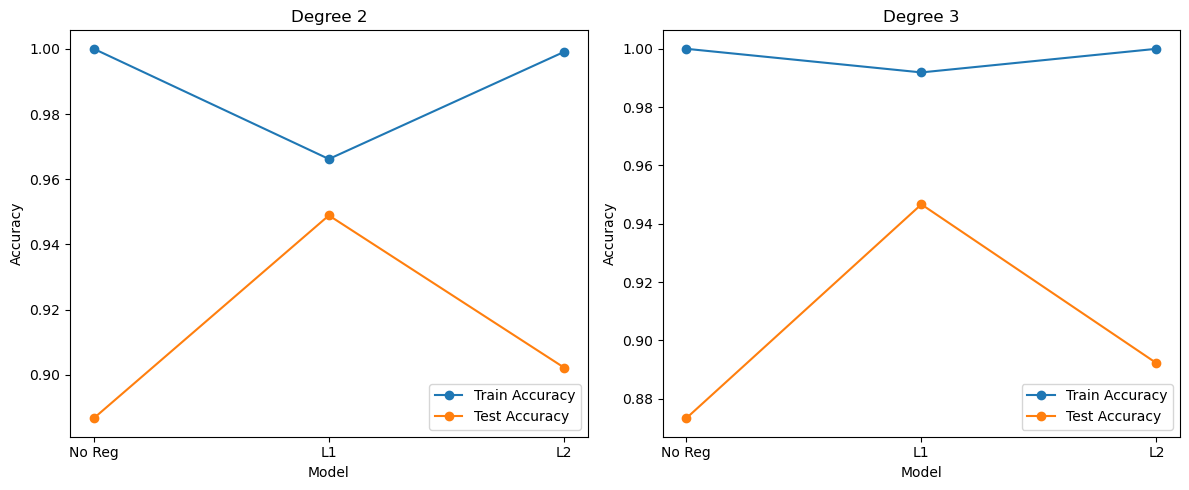

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1) Generate data
X, y = make_classification(
    n_samples=3000,
    n_features=50,
    n_informative=10,
    n_redundant=10,
    random_state=42
)

# 2) Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3) Function to build models
def create_model(degree, reg_type):
    if reg_type == "none":
        return Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000))
        ])
    elif reg_type == "l1":
        return Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=5000))
        ])
    elif reg_type == "l2":
        return Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(penalty='l2', solver='lbfgs', C=0.1, max_iter=5000))
        ])

# 4) Degrees
degrees = [2, 3]

# 5) Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, degree in enumerate(degrees):

    train_acc = []
    test_acc = []
    labels = ['No Reg', 'L1', 'L2']
    regs = ['none', 'l1', 'l2']

    for reg in regs:
        model = create_model(degree, reg)
        model.fit(X_train, y_train)

        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Accuracy
        train_acc.append(accuracy_score(y_train, y_train_pred))
        test_acc.append(accuracy_score(y_test, y_test_pred))

    # Plot for this degree
    ax = axes[i]
    x = np.arange(len(labels))

    ax.plot(x, train_acc, marker='o', label='Train Accuracy')
    ax.plot(x, test_acc, marker='o', label='Test Accuracy')

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(f"Degree {degree}")
    ax.set_xlabel("Model")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.tight_layout()
plt.show()

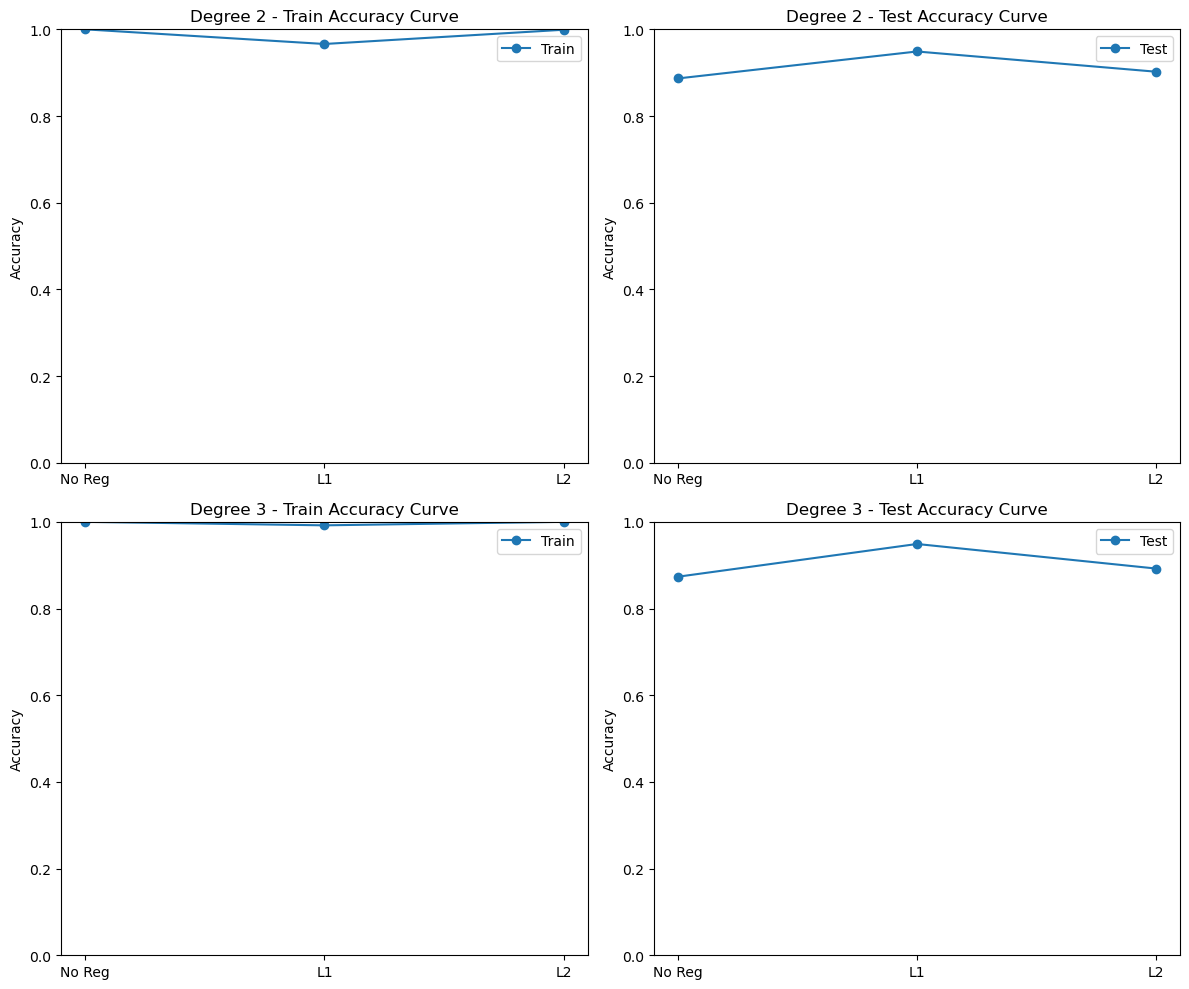

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1) Generate dataset
X, y = make_classification(
    n_samples=3000,
    n_features=50,
    n_informative=10,
    n_redundant=10,
    random_state=42
)

# 2) Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3) Model builder
def create_model(degree, reg_type):
    if reg_type == "none":
        return Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(penalty=None, solver='lbfgs', max_iter=5000))
        ])
    elif reg_type == "l1":
        return Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=5000))
        ])
    elif reg_type == "l2":
        return Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('log_reg', LogisticRegression(penalty='l2', solver='lbfgs', C=0.1, max_iter=5000))
        ])

# 4) Setup
degrees = [2, 3]
model_names = ['No Reg', 'L1', 'L2']
reg_types = ['none', 'l1', 'l2']

# 5) Create 4 graphs
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, degree in enumerate(degrees):

    train_acc = []
    test_acc = []

    for reg in reg_types:
        model = create_model(degree, reg)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_acc.append(accuracy_score(y_train, y_train_pred))
        test_acc.append(accuracy_score(y_test, y_test_pred))

    x = np.arange(len(model_names))

    # Graph 1: Degree X - Train curve
    axes[i, 0].plot(x, train_acc, marker='o', label='Train')
    axes[i, 0].set_title(f"Degree {degree} - Train Accuracy Curve")
    axes[i, 0].set_xticks(x)
    axes[i, 0].set_xticklabels(model_names)
    axes[i, 0].set_ylabel("Accuracy")
    axes[i, 0].set_ylim(0, 1)
    axes[i, 0].legend()

    # Graph 2: Degree X - Test curve
    axes[i, 1].plot(x, test_acc, marker='o', label='Test')
    axes[i, 1].set_title(f"Degree {degree} - Test Accuracy Curve")
    axes[i, 1].set_xticks(x)
    axes[i, 1].set_xticklabels(model_names)
    axes[i, 1].set_ylabel("Accuracy")
    axes[i, 1].set_ylim(0, 1)
    axes[i, 1].legend()

plt.tight_layout()
plt.show()